# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [2]:
df = pd.read_csv("Accounts.csv")

In [3]:
print("Shape", df.shape) 
df.head()

Shape (95000, 7)


,account_id,customer_id,branch_id,account_type,balance,open_date,status
0,1,11749,141,Current,95902.00,10/20/2019,Active
1,2,47716,43,Current,13261.61,2/3/2026,Active
2,3,56143,90,Savings,26495.92,10/19/2020,Active
3,4,29193,113,Salary,74682.72,2/22/2012,Active
4,5,49907,28,Current,40419.01,1/3/2007,Active


In [4]:
# Collecting Info About Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  object 
 6   status        95000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.1+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
account_id,95000.0,47500.500000,27424.282124,1.00,23750.7500,47500.500,71250.250,95000.00
customer_id,95000.0,29991.208179,17264.584944,1.00,15114.7500,30000.000,44910.000,60000.00
branch_id,95000.0,75.450695,43.295402,1.00,38.0000,75.000,113.000,150.00
balance,95000.0,45761.236422,45306.411751,500.36,13551.0475,31768.655,63337.515,539198.59


# Data Cleaning & Standardization
Checks: missing values, duplicate rows, duplicate primary keys, data type correction, whitespace/case standardization for categorical text fields, and date parsing.

In [6]:
print("Missing VAlues Per Column")
print(df.isna().sum())

print(f"Duplicated Rows:",df.duplicated().sum())
print(f"Duplicated Account Id: ",df["account_id"].duplicated().sum())

Missing VAlues Per Column
account_id      0
customer_id     0
branch_id       0
account_type    0
balance         0
open_date       0
status          0
dtype: int64
Duplicated Rows: 0
Duplicated Account Id:  0


In [7]:
# Change Data Type Of Open_Date Column (Object) To DateTime

df["open_date"]=pd.to_datetime(df["open_date"])

In [8]:
print(df["account_type"].unique())
print(df["status"].unique())

['Current' 'Savings' 'Salary' 'Fixed Deposit' 'NRI']
['Active' 'Dormant' 'Closed']


In [9]:
# Sanity check on value ranges (negative/zero balances, future dates)
print("Min balance:", df['balance'].min(), " | Max balance:", df['balance'].max())
print("Negative balances:", (df['balance'] < 0).sum())
print("Date range:", df['open_date'].min().date(), "to", df['open_date'].max().date())
print("Future-dated accounts (after today):", (df['open_date'] > pd.Timestamp.today()).sum())

Min balance: 500.36  | Max balance: 539198.59
Negative balances: 0
Date range: 2005-01-01 to 2026-05-31
Future-dated accounts (after today): 0


In [10]:
# Feature Engineering

In [11]:
# Date-derived features 
today = pd.Timestamp('2026-08-06')  # analysis reference date
df['open_year'] = df['open_date'].dt.year
df['open_month'] = df['open_date'].dt.month
df['open_weekday'] = df['open_date'].dt.day_name()
df['is_weekend_open'] = df['open_date'].dt.dayofweek >= 5
df['account_age_years'] = ((today - df['open_date']).dt.days / 365.25).round(2)

# Balance-derived features
df['balance_category'] = pd.cut(
    df['balance'],
    bins=[0, 10000, 50000, 150000, np.inf],
    labels=['Low (<10K)', 'Medium (10K-50K)', 'High (50K-150K)', 'Very High (150K+)']
)

# IQR-based outlier flag on balance
q1, q3 = df['balance'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
df['is_balance_outlier'] = df['balance'] > upper_fence

# --- Customer-level features ---
accounts_per_customer = df.groupby('customer_id')['account_id'].transform('count')
df['accounts_per_customer'] = accounts_per_customer
df['is_multi_account_customer'] = df['accounts_per_customer'] > 1

df[['open_year','open_month','open_weekday','is_weekend_open',
    'account_age_years','balance_category','is_balance_outlier',
    'accounts_per_customer','is_multi_account_customer']].head()

,open_year,open_month,open_weekday,is_weekend_open,account_age_years,balance_category,is_balance_outlier,accounts_per_customer,is_multi_account_customer
0,2019,10,Sunday,True,6.80,High (50K-150K),False,2,True
1,2026,2,Tuesday,False,0.50,Medium (10K-50K),False,1,False
2,2020,10,Monday,False,5.80,Medium (10K-50K),False,1,False
3,2012,2,Wednesday,False,14.45,High (50K-150K),False,1,False
4,2007,1,Wednesday,False,19.59,Medium (10K-50K),False,4,True


In [12]:
# Total Features
df.head()

,account_id,customer_id,branch_id,account_type,balance,open_date,status,open_year,open_month,open_weekday,is_weekend_open,account_age_years,balance_category,is_balance_outlier,accounts_per_customer,is_multi_account_customer
0,1,11749,141,Current,95902.00,2019-10-20,Active,2019,10,Sunday,True,6.80,High (50K-150K),False,2,True
1,2,47716,43,Current,13261.61,2026-02-03,Active,2026,2,Tuesday,False,0.50,Medium (10K-50K),False,1,False
2,3,56143,90,Savings,26495.92,2020-10-19,Active,2020,10,Monday,False,5.80,Medium (10K-50K),False,1,False
3,4,29193,113,Salary,74682.72,2012-02-22,Active,2012,2,Wednesday,False,14.45,High (50K-150K),False,1,False
4,5,49907,28,Current,40419.01,2007-01-03,Active,2007,1,Wednesday,False,19.59,Medium (10K-50K),False,4,True


# Data Visualization


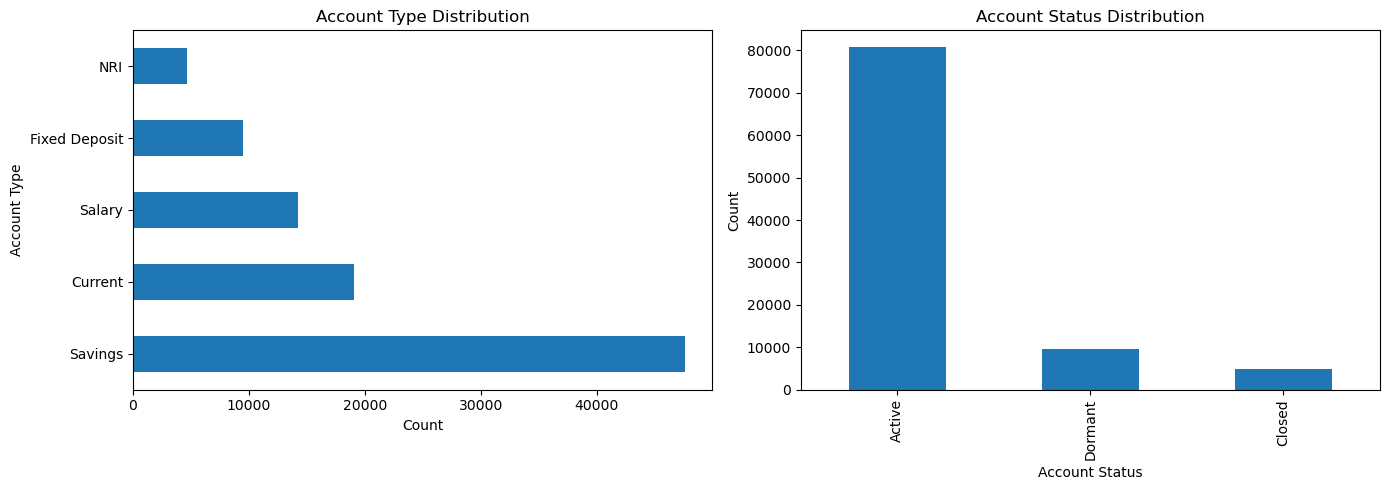

In [13]:
import matplotlib.pyplot as plt

# Create two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["account_type"].value_counts().plot(
    kind="barh",
    ax=axes[0]
)

axes[0].set_xlabel("Count")
axes[0].set_ylabel("Account Type")
axes[0].set_title("Account Type Distribution")


df["status"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_xlabel("Account Status")
axes[1].set_ylabel("Count")
axes[1].set_title("Account Status Distribution")

plt.tight_layout()

plt.savefig("chart_categorical_dist.png", dpi=120)

# Show Figure
plt.show()

# Blance Distribution

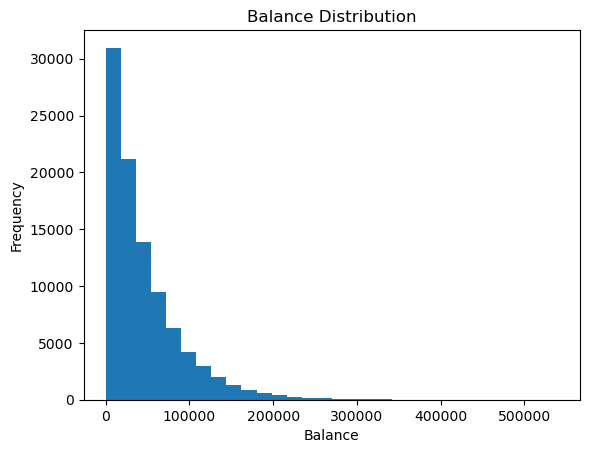

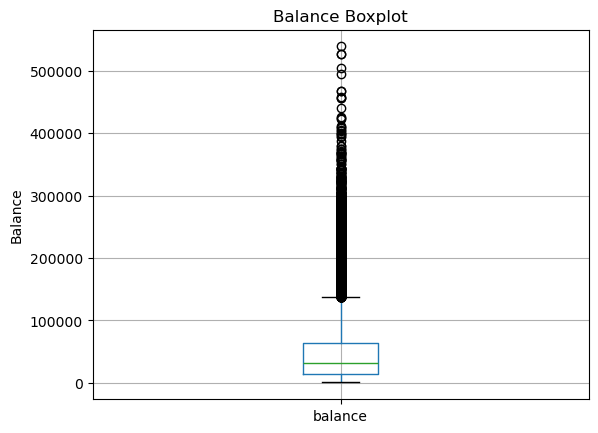

Skewness: 2.02
Number of Outliers: 4498


In [14]:
import matplotlib.pyplot as plt

# Histogram of Balance
df["balance"].plot(kind="hist", bins=30)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

# Boxplot of Balance
df.boxplot(column="balance")

plt.title("Balance Boxplot")
plt.ylabel("Balance")
plt.show()

# Skewness
print("Skewness:", round(df["balance"].skew(), 2))

# Number of Outliers
print("Number of Outliers:", df["is_balance_outlier"].sum())

# Balance By Account Type And Status

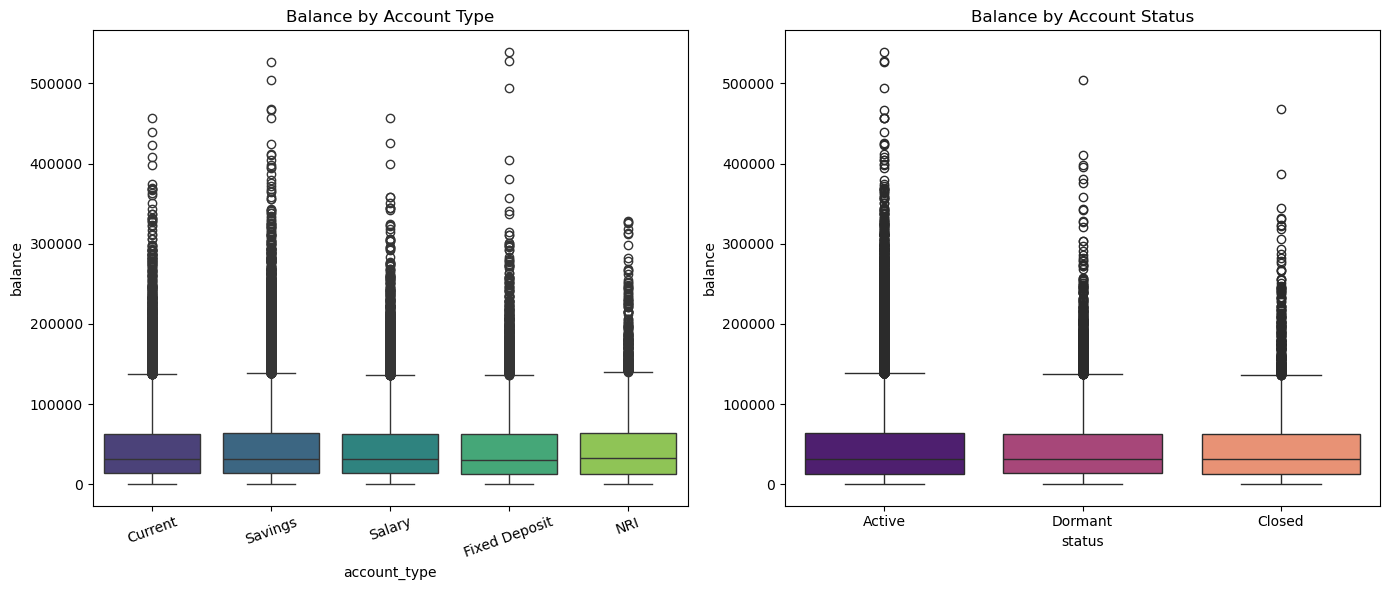

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='account_type', y='balance', hue='account_type', legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Balance by Account Type')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='status', y='balance', hue='status', legend=False, ax=axes[1], palette='magma')
axes[1].set_title('Balance by Account Status')

plt.tight_layout()
plt.savefig('chart_balance_by_cat.png', dpi=120)
plt.show()

# Account Opening Over Time

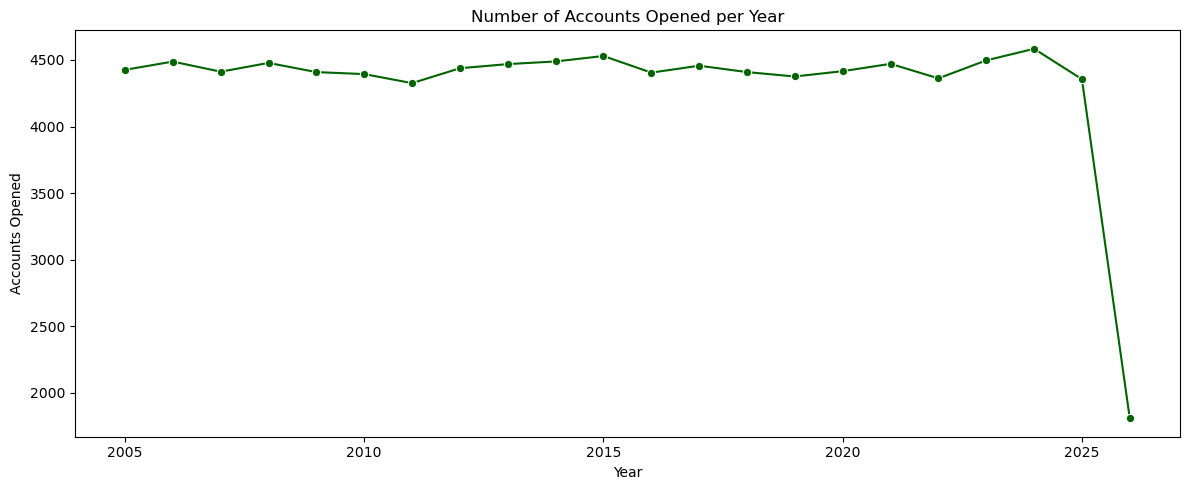

In [16]:
yearly = df.groupby('open_year').size()

plt.figure(figsize=(12,5))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='darkgreen')
plt.title('Number of Accounts Opened per Year')
plt.xlabel('Year')
plt.ylabel('Accounts Opened')
plt.tight_layout()
plt.show()

# Account Open In Months


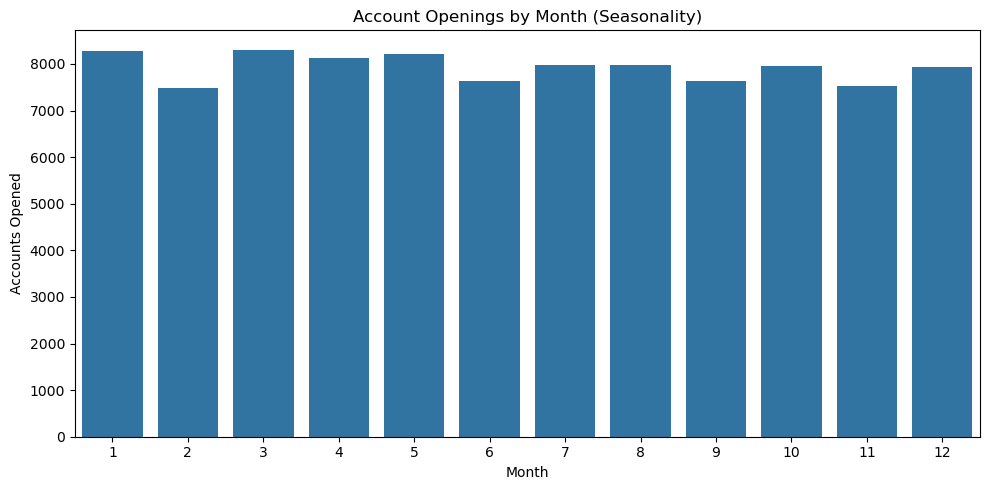

In [17]:
monthly = df.groupby('open_month').size()

plt.figure(figsize=(10,5))
sns.barplot(x=monthly.index, y=monthly.values)
plt.title('Account Openings by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Accounts Opened')
plt.tight_layout()
plt.show()

# Branch Wise Performance

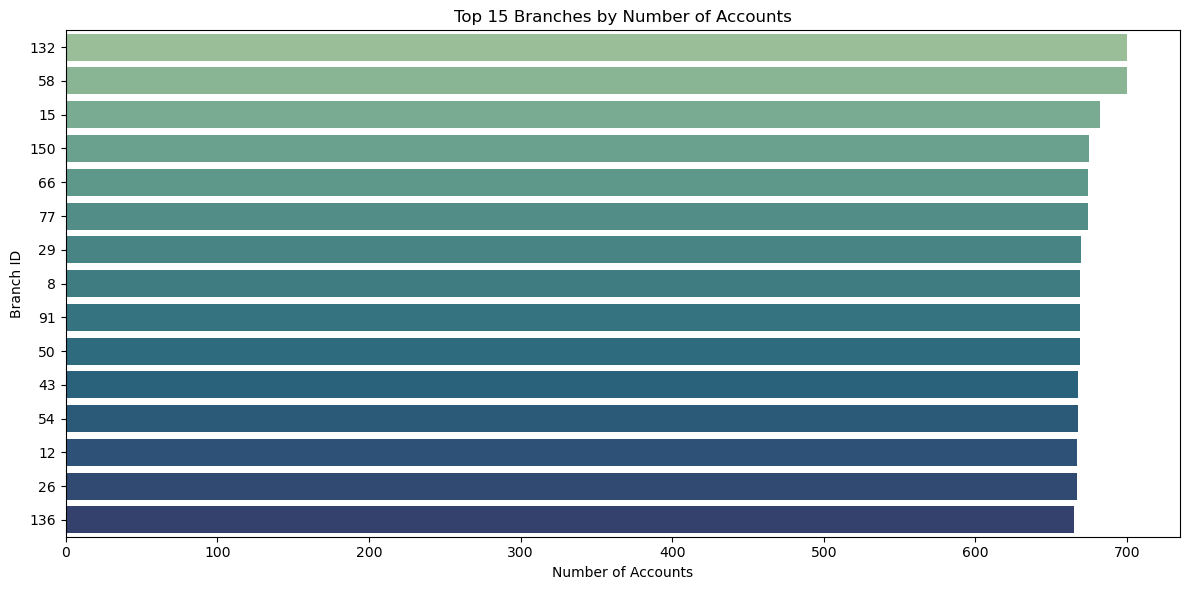

,total_accounts,total_balance,avg_balance
branch_id,,,
132,700,31837894.48,45482.706400
58,700,31969232.54,45670.332200
15,682,31435234.17,46092.718724
150,675,31889032.84,47243.011615
66,674,30771715.18,45655.363769
77,674,30937762.89,45901.725356
29,670,32047429.89,47831.984910
8,669,32396876.95,48425.825037
91,669,29558703.99,44183.414036


In [18]:
branch_summary = df.groupby('branch_id').agg(
    total_accounts=('account_id','count'),
    total_balance=('balance','sum'),
    avg_balance=('balance','mean')
).sort_values('total_accounts', ascending=False)

top15 = branch_summary.head(15)

plt.figure(figsize=(12,6))
sns.barplot(x=top15['total_accounts'], y=top15.index.astype(str), hue=top15.index.astype(str), legend=False, palette='crest')
plt.title('Top 15 Branches by Number of Accounts')
plt.xlabel('Number of Accounts'); plt.ylabel('Branch ID')
plt.tight_layout()
plt.show()

branch_summary.head(10)

# Customer Behaviour Multi Account Holder

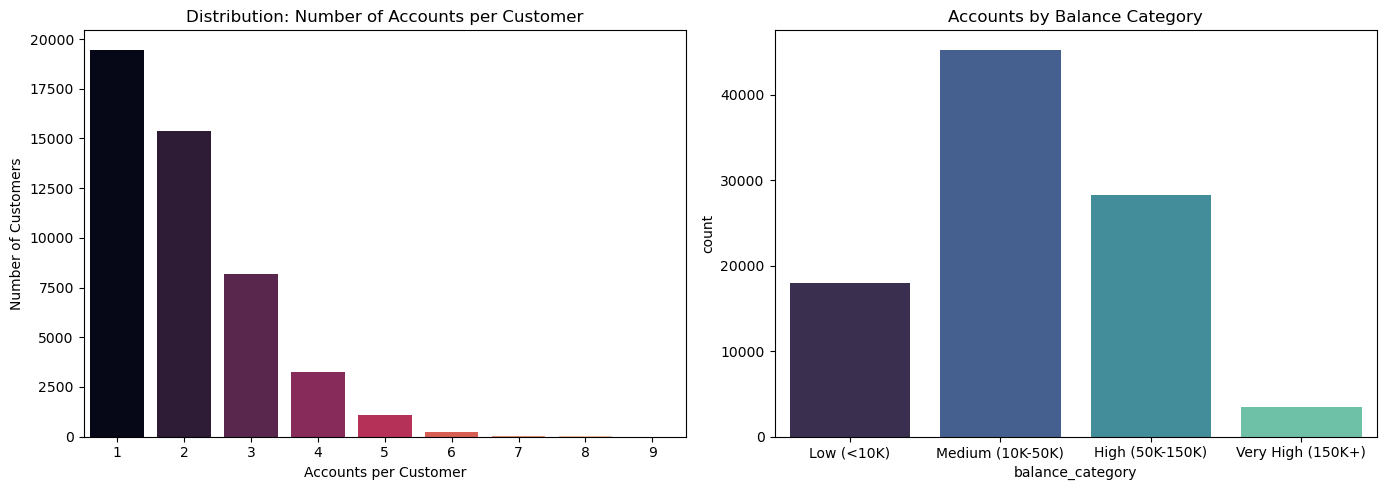

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

acct_counts = df.drop_duplicates('customer_id')['accounts_per_customer'].value_counts().sort_index()
sns.barplot(x=acct_counts.index, y=acct_counts.values, hue=acct_counts.index, legend=False, ax=axes[0], palette='rocket')
axes[0].set_title('Distribution: Number of Accounts per Customer')
axes[0].set_xlabel('Accounts per Customer'); axes[0].set_ylabel('Number of Customers')

sns.countplot(data=df, x='balance_category', hue='balance_category', legend=False, ax=axes[1], palette='mako',
              order=['Low (<10K)','Medium (10K-50K)','High (50K-150K)','Very High (150K+)'])
axes[1].set_title('Accounts by Balance Category')


plt.tight_layout()

plt.show()

# Coreation Heatmap Numeric Values

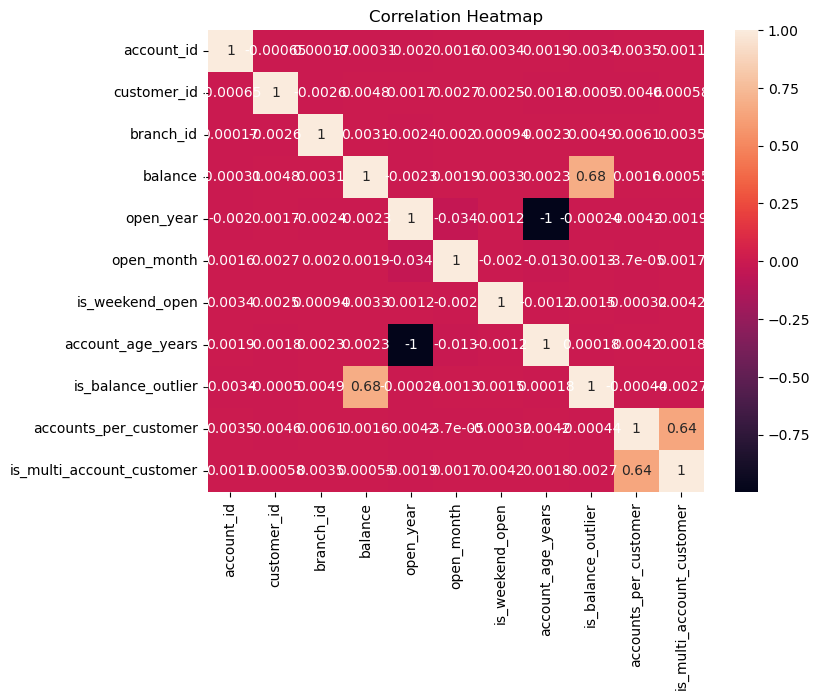

In [20]:


corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

# Status Vs Account Type

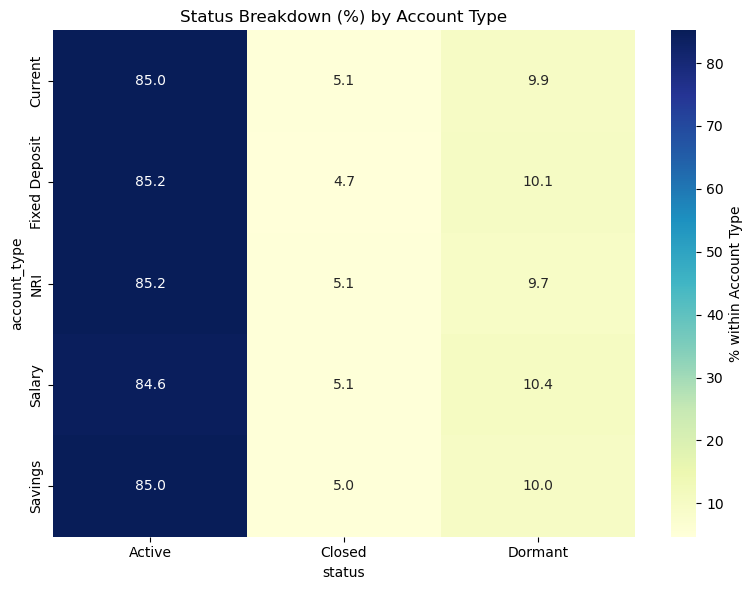

status,Active,Closed,Dormant
account_type,,,
Current,16161,970,1890
Fixed Deposit,8054,445,959
NRI,3999,240,455
Salary,12066,722,1482
Savings,40427,2390,4740


In [21]:
cross = pd.crosstab(df['account_type'], df['status'])
cross_pct = pd.crosstab(df['account_type'], df['status'], normalize='index') * 100

plt.figure(figsize=(8,6))
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label':'% within Account Type'})
plt.title('Status Breakdown (%) by Account Type')
plt.tight_layout()

plt.show()

cross

In [25]:
df.head()

,account_id,customer_id,branch_id,account_type,balance,open_date,status,open_year,open_month,open_weekday,is_weekend_open,account_age_years,balance_category,is_balance_outlier,accounts_per_customer,is_multi_account_customer
0,1,11749,141,Current,95902.00,2019-10-20,Active,2019,10,Sunday,True,6.80,High (50K-150K),False,2,True
1,2,47716,43,Current,13261.61,2026-02-03,Active,2026,2,Tuesday,False,0.50,Medium (10K-50K),False,1,False
2,3,56143,90,Savings,26495.92,2020-10-19,Active,2020,10,Monday,False,5.80,Medium (10K-50K),False,1,False
3,4,29193,113,Salary,74682.72,2012-02-22,Active,2012,2,Wednesday,False,14.45,High (50K-150K),False,1,False
4,5,49907,28,Current,40419.01,2007-01-03,Active,2007,1,Wednesday,False,19.59,Medium (10K-50K),False,4,True
